Имеются данные о продаже товаров в продуктовом интернет-магазине

In [1]:
import pandas as pd

In [8]:
df = pd.read_csv('/content/Customers.csv', sep = ';', decimal=",")

In [9]:
df

,Number,Customer_id,Prices,Date
0,1234491,337544.0,539.00,01.01.2018
1,1234494,171642.0,153.30,01.01.2018
2,1234497,260596.0,55.30,01.01.2018
3,1234498,1105609.0,752.50,01.01.2018
4,1234500,982696.0,4410.00,01.01.2018
...,...,...,...,...
1048570,4128741,745815.0,489.30,13.03.2019
1048571,4128746,3343412.0,734.30,13.03.2019
1048572,4128752,451277.0,1757.00,13.03.2019
1048573,4128755,135078.0,4650.10,13.03.2019


Далее проведем некоторый анализ этих данных на предмет их формата и типа данных, а также определение числовых и нечисловых данных:

In [10]:
#выведем формат и тип данных
print(df.shape)
print(df.dtypes)

(1048575, 4)
Number           int64
Customer_id    float64
Prices          object
Date            object
dtype: object


По выведенным значениям видно, что колонки Number и Customer_id являются числовыми, а Date и Prices является нечисловой. По нечисловым данным описательная статистика не рассчитается, поэтому переведем столбец «Prices» в числовой вид с помощью метода .astype(float):

In [11]:
 # преобразуем данные
df = df[['Prices', 'Number', 'Customer_id']].astype(float)

Колонкой дата в нашем задании можно пренебречь. После этого посмотрим какие колонки в таблице относятся к численным значениям, а какие нет:

In [12]:
# выберем числовые данные. Для этого нам потребуется добавить библиотеку numpy.
import numpy as np
# выберем числовые колонки
df_numeric = df.select_dtypes(include=[np.number])
numeric_cols = df_numeric.columns.values
print(numeric_cols)
# выберем нечисловые колонки
df_non_numeric = df.select_dtypes(exclude=[np.number])
non_numeric_cols = df_non_numeric.columns.values
print(non_numeric_cols)

['Prices' 'Number' 'Customer_id']
[]


Далее проведем описательную статистику:

In [13]:
# Описательная статистика
print(df.describe())

             Prices        Number   Customer_id
count  1.048575e+06  1.048575e+06  1.048566e+06
mean   2.136475e+03  2.570549e+06  1.485835e+06
std    3.243518e+03  8.434932e+05  8.833536e+05
min   -3.430000e+01  1.234491e+06  0.000000e+00
25%    7.049000e+02  1.804274e+06  7.050775e+05
50%    1.358000e+03  2.524455e+06  1.438339e+06
75%    2.422000e+03  3.291542e+06  2.124041e+06
max    8.190966e+05  4.128758e+06  3.343412e+06


Следующим шагом проверим таблицу на отсутствующие значения:

<Axes: >

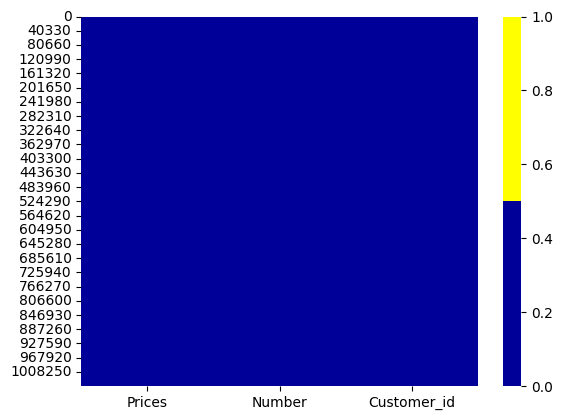

In [14]:
# Тепловая карта отсутствующих данных (Missing Data Heatmap)
# Добавляем библиотеку seaborn
import seaborn as sns
cols = df.columns[:4] # выбираем первые 4 колонки
colours = ['#000099', '#ffff00'] # определите цвета - желтые – это пропущенные. синие - не пропущенные.
sns.heatmap(df[cols].isnull(), cmap=sns.color_palette(colours))

In [18]:
round(df[cols].isnull().sum() / len(df) * 100, 4) # %

(Prices         0.0000
 Number         0.0000
 Customer_id    0.0009
 dtype: float64,
 '%')

Обнаружено, что у 0.0009% покупок не прописан Customer_id покупателя. Так как данный показатель не является критическим, а остальные показатели в строке присутствуют, заменим пропущенные значения медианным, равным 1438339:

In [21]:
# Решение проблемы пропущенных данных.
# заменим пропущенные значения медианой
median = df['Customer_id'].median()
print(median)
df['Customer_id'] = df['Customer_id'].fillna(median)
# Проверка:
# Проверка пропущенных данных после замены пропущенных значений медианой
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing*100))#

1438339.0
Prices - 0.0%
Number - 0.0%
Customer_id - 0.0%


Все пропущенные значения устранены.

Далее визуализируем разброс значений по переменной Prices, используя диаграмму рассеяния.

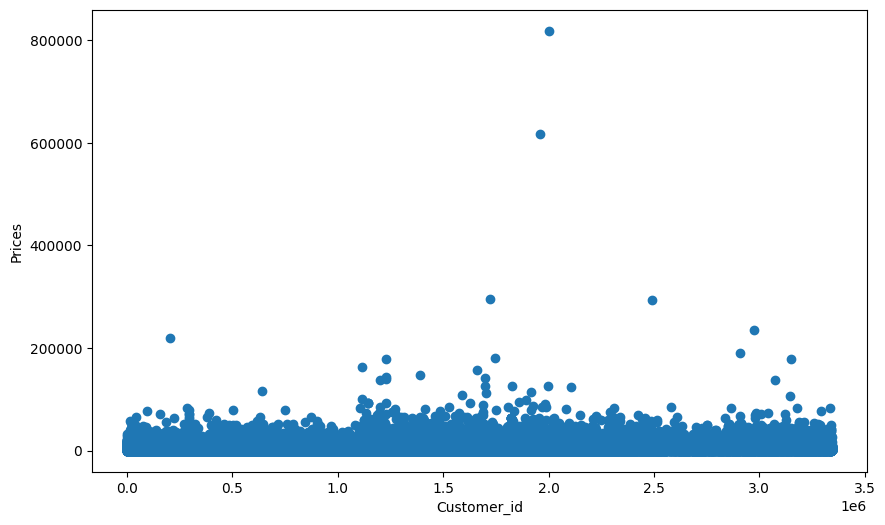

2136.474525093579
   Prices     Number  Customer_id
0   539.0  1234491.0     337544.0
1   153.3  1234494.0     171642.0
2    55.3  1234497.0     260596.0
3   752.5  1234498.0    1105609.0
4  4410.0  1234500.0     982696.0


In [22]:
#Выявление выбросов
import matplotlib.pyplot as plt
#Визуализация разброса значений по Prices
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = df['Customer_id'], y = df['Prices'])
plt.xlabel("Customer_id")
plt.ylabel("Prices")
plt.show()

print(df.Prices.mean())
print(df.head())

Из диаграммы следует, что в совокупности присутствуют выпадающие значения, которые необходимо удалять или заменять средними значениями (или медианами).